# MA #1 MONEYBALL OLS REGRESSION PROJECT
School of Professional Studies | Northwestern University

50 Points Total

---

Over the next four weeks, you will analyze the Moneyball dataset using linear regression. This first assignment focuses on exploratory data analysis (EDA) and building a baseline model to predict wins for a baseball team. 

The dataset contains approximately 2,200 records, each representing a professional baseball team from 1871 to 2006. All statistics are adjusted to reflect a 162-game season. You must use OLS (Linear Regression) with the provided variables - or variables you derive from them - to predict TARGET_WINS. 

---

**DELIVERABLES**
- **Write-up (PDF or HTML)**. Four clearly labeled sections with enough detail for me to follow your reasoning and for a third party to replicate your work. Jupyter Notebooks exported as HTML are accepted.
- **R Code (Python) file**. A single file containing all code used in your analysis. I must be able to run it and reproduce your output exactly.
- **Scored predictions (CSV)**. Scored records from `test.csv`, with exactly two columns: **INDEX** and **P_TARGET_WINS**

---
## Section 1: Exploratory Data Analysis

Goal: develop intuition about the Moneyball dataset (team-season batting/pitching/fielding/baserunning stats, 1871-2006, adjusted to a 162-game season) before any modeling. 

### 1. Setup and Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [4]:
# Load train and test sets
train = pd.read_csv('moneyball_train.csv', index_col=0)
test = pd.read_csv('moneyball_test.csv', index_col=0)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
train.head()

Train shape: (2276, 17)
Test shape: (259, 16)


,INDEX,TARGET_WINS,TEAM_BATTING_H,TEAM_BATTING_2B,TEAM_BATTING_3B,TEAM_BATTING_HR,TEAM_BATTING_BB,TEAM_BATTING_SO,TEAM_BASERUN_SB,TEAM_BASERUN_CS,TEAM_BATTING_HBP,TEAM_PITCHING_H,TEAM_PITCHING_HR,TEAM_PITCHING_BB,TEAM_PITCHING_SO,TEAM_FIELDING_E,TEAM_FIELDING_DP
0,1.0,39.0,1445.0,194.0,39.0,13.0,143.0,842.0,NaN,NaN,NaN,9364.0,84.0,927.0,5456.0,1011.0,NaN
1,2.0,70.0,1339.0,219.0,22.0,190.0,685.0,1075.0,37.0,28.0,NaN,1347.0,191.0,689.0,1082.0,193.0,155.0
2,3.0,86.0,1377.0,232.0,35.0,137.0,602.0,917.0,46.0,27.0,NaN,1377.0,137.0,602.0,917.0,175.0,153.0
3,4.0,70.0,1387.0,209.0,38.0,96.0,451.0,922.0,43.0,30.0,NaN,1396.0,97.0,454.0,928.0,164.0,156.0
4,5.0,82.0,1297.0,186.0,27.0,102.0,472.0,920.0,49.0,39.0,NaN,1297.0,102.0,472.0,920.0,138.0,168.0


In [6]:
train.describe()

,INDEX,TARGET_WINS,TEAM_BATTING_H,TEAM_BATTING_2B,TEAM_BATTING_3B,TEAM_BATTING_HR,TEAM_BATTING_BB,TEAM_BATTING_SO,TEAM_BASERUN_SB,TEAM_BASERUN_CS,TEAM_BATTING_HBP,TEAM_PITCHING_H,TEAM_PITCHING_HR,TEAM_PITCHING_BB,TEAM_PITCHING_SO,TEAM_FIELDING_E,TEAM_FIELDING_DP
count,2276.000000,2276.000000,2276.000000,2276.000000,2276.000000,2276.000000,2276.000000,2174.000000,2145.000000,1504.000000,191.000000,2276.000000,2276.000000,2276.000000,2174.000000,2276.000000,1990.000000
mean,1268.463533,80.790861,1469.269772,241.246924,55.250000,99.612039,501.558875,735.605336,124.761772,52.803856,59.356021,1779.210457,105.698594,553.007909,817.730451,246.480668,146.387940
std,736.349040,15.752152,144.591195,46.801415,27.938557,60.546872,122.670862,248.526418,87.791166,22.956338,12.967123,1406.842930,61.298747,166.357362,553.085031,227.770972,26.226385
min,1.000000,0.000000,891.000000,69.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,1137.000000,0.000000,0.000000,0.000000,65.000000,52.000000
25%,630.750000,71.000000,1383.000000,208.000000,34.000000,42.000000,451.000000,548.000000,66.000000,38.000000,50.500000,1419.000000,50.000000,476.000000,615.000000,127.000000,131.000000
50%,1270.500000,82.000000,1454.000000,238.000000,47.000000,102.000000,512.000000,750.000000,101.000000,49.000000,58.000000,1518.000000,107.000000,536.500000,813.500000,159.000000,149.000000
75%,1915.500000,92.000000,1537.250000,273.000000,72.000000,147.000000,580.000000,930.000000,156.000000,62.000000,67.000000,1682.500000,150.000000,611.000000,968.000000,249.250000,164.000000
max,2535.000000,146.000000,2554.000000,458.000000,223.000000,264.000000,878.000000,1399.000000,697.000000,201.000000,95.000000,30132.000000,343.000000,3645.000000,19278.000000,1898.000000,228.000000


In [8]:
test.describe()

,INDEX,TEAM_BATTING_H,TEAM_BATTING_2B,TEAM_BATTING_3B,TEAM_BATTING_HR,TEAM_BATTING_BB,TEAM_BATTING_SO,TEAM_BASERUN_SB,TEAM_BASERUN_CS,TEAM_BATTING_HBP,TEAM_PITCHING_H,TEAM_PITCHING_HR,TEAM_PITCHING_BB,TEAM_PITCHING_SO,TEAM_FIELDING_E,TEAM_FIELDING_DP
count,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,241.000000,246.000000,172.000000,19.000000,259.000000,259.000000,259.000000,241.000000,259.000000,228.000000
mean,1263.926641,1469.389961,241.320463,55.911197,95.633205,498.957529,709.336100,123.703252,52.319767,62.368421,1813.463320,102.146718,552.416988,799.668050,249.749035,146.057018
std,693.288673,150.655231,49.516124,27.144100,56.332215,120.592152,243.111135,93.387963,23.104569,12.706999,1662.913079,57.654895,172.950064,634.305846,230.902599,25.883870
min,9.000000,819.000000,44.000000,14.000000,0.000000,15.000000,0.000000,0.000000,0.000000,42.000000,1155.000000,0.000000,136.000000,0.000000,73.000000,69.000000
25%,708.000000,1387.000000,210.000000,35.000000,44.500000,436.500000,545.000000,59.000000,38.000000,53.500000,1426.500000,52.000000,471.000000,613.000000,131.000000,131.000000
50%,1249.000000,1455.000000,239.000000,52.000000,101.000000,509.000000,686.000000,92.000000,49.500000,62.000000,1515.000000,104.000000,526.000000,745.000000,163.000000,148.000000
75%,1832.500000,1548.000000,278.500000,72.000000,135.500000,565.500000,912.000000,151.750000,63.000000,67.500000,1681.000000,142.500000,606.500000,938.000000,252.000000,164.000000
max,2525.000000,2170.000000,376.000000,155.000000,242.000000,792.000000,1268.000000,580.000000,154.000000,96.000000,22768.000000,336.000000,2008.000000,9963.000000,1568.000000,204.000000


### 1.1 Verifying INDEX Integrity

`INDEX` is the record identifier used to match predictions. We need to confirm that train and test together form one consistent, non-overlapping split of the original dataset

In [10]:
train_idx = set(train['INDEX'])
test_idx = set(test['INDEX'])

overlap = train_idx & test_idx
combined = train_idx | test_idx
full_range = set(range(int(min(combined)), int(max(combined)) + 1))
gaps = full_range - combined

print(f"Train INDEX range: {min(train_idx):.0f} to {max(train_idx):.0f}  (n={len(train_idx)})")
print(f"Test INDEX range:  {min(test_idx):.0f} to {max(test_idx):.0f}  (n={len(test_idx)})")
print(f"Overlap between train and test INDEX: {len(overlap)}")
print(f"Gaps left unexplained once train+test are combined: {len(gaps)}")

Train INDEX range: 1 to 2535  (n=2276)
Test INDEX range:  9 to 2525  (n=259)
Overlap between train and test INDEX: 0
Gaps left unexplained once train+test are combined: 0


Train and test INDEX values are mutually exclusive and together cover the full original ID range with no gaps. This confirms train/test is a clean split of one source dataset, and that `INDEX` is the correct identifier to carry through to the final scored-predictions CSV. 

### 1.2 Missing Data Overview

In [12]:
missing_summary = pd.DataFrame({
    'n_missing_train': train.isna().sum(),
    'pct_missing_train': (train.isna().mean() * 100).round(1),
    'n_missing_test': test.reindex(columns=train.columns).isna().sum(),
    'pct_missing_test': (test.reindex(columns=train.columns).isna().mean() * 100).round(1),
}).drop(index=['TARGET_WINS'], errors='ignore')

missing_summary.sort_values('pct_missing_train', ascending=False)

,n_missing_train,pct_missing_train,n_missing_test,pct_missing_test
TEAM_BATTING_HBP,2085,91.6,240,92.7
TEAM_BASERUN_CS,772,33.9,87,33.6
TEAM_FIELDING_DP,286,12.6,31,12.0
TEAM_BASERUN_SB,131,5.8,13,5.0
TEAM_BATTING_SO,102,4.5,18,6.9
TEAM_PITCHING_SO,102,4.5,18,6.9
INDEX,0,0.0,0,0.0
TEAM_BATTING_H,0,0.0,0,0.0
TEAM_BATTING_2B,0,0.0,0,0.0
TEAM_BATTING_3B,0,0.0,0,0.0


### 1.3 Out-of-Range Value Detection

While reviewing `TEAM_PITCHING_SO`, I found a small number of records with implausible values (e.g., >19,000 strikeouts allowed in a 162 game season). Investigation showed this concentrated in a cluster of related "pitching-against"/fielding columns simultaneously (`TEAM_PITCHING_H`, `TEAM_PITCHING_BB`, `TEAM_PITCHING_SO`, `TEAM_FIELDING_E`), with ratios to the team's own batting numbers that repeat across rows (e.g., 2.70x appearing on multiple separate records). This is consistent with a normalization artifact tied to converting older, shorter real seasons to a 162-game-equivalent basis, rather than with genuinely extreme (but real) performances. 

**Detection Rule**; for each of the four columns above, flag a value as an outlier if it falls outside Tukey's rule: above `Q3 + 1.5 * IQR`. A row is treated as corrupted if it is flagged in at least 2 out of the 4 columns simultaneously. Single-column outliers were checked and are consistent with ordinary bad seasons, while every previously-identified corrupted record was flagged in 2 or more columns. 

**Solution**: for rows meeting this rule, the four affected column values are set to missing, to be handled consistenly alongside genuinely missing data. 

**Widening the repair**: the same 191 rows were also checked against `TEAM_BATTING_HR`, `TEAM_PITCHING_HR`, and `TEAM_BATTING_SO`. These three columns were not part of the original detection rule. All three came back abnormally low for this group relative to the rest of the dataset, confirming the same corruption mechanism reaches further than the four columns originally checked. Rather than writing a second, separate rule, these three columns are folded into the same repair for the same 191 rows. 

In [14]:
outlier_cols = ['TEAM_PITCHING_H', 'TEAM_PITCHING_BB', 'TEAM_PITCHING_SO', 'TEAM_FIELDING_E']

outlier_flags = pd.DataFrame(index=train.index)
bounds = {}
for c in outlier_cols:
    q1, q3 = train[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    bounds[c] = upper
    outlier_flags[c] = train[c] > upper

n_flags = outlier_flags[outlier_cols].sum(axis=1)
corrupted_rows = n_flags >= 2

print("Upper-bound thresholds used:")
for c, u in bounds.items():
    print(f" {c}: flag if > {u:.0f}")
print()
print(f"Rows flagged in >=2 of the 4 columns (treated as corrupted): {corrupted_rows.sum()}")
print(f"Rows flagged in exactly 1 column (treated as legitimate, left as-is): {(n_flags == 1).sum()}")

Upper-bound thresholds used:
 TEAM_PITCHING_H: flag if > 2078
 TEAM_PITCHING_BB: flag if > 814
 TEAM_PITCHING_SO: flag if > 1498
 TEAM_FIELDING_E: flag if > 433

Rows flagged in >=2 of the 4 columns (treated as corrupted): 191
Rows flagged in exactly 1 column (treated as legitimate, left as-is): 179


In [16]:
extra_suspect_cols = ['TEAM_BATTING_HR', 'TEAM_PITCHING_HR', 'TEAM_BATTING_SO']

print("Checking whether the same 191 corrupted rows are also distorted in these columns:")
for c in extra_suspect_cols:
    n_zero = (train.loc[corrupted_rows, c] == 0).sum()
    print(f"  {c}: mean = {train.loc[corrupted_rows, c].mean():.1f} "
          f"(vs overall mean {train[c].mean():.1f})  |  exactly 0 in {n_zero}/{corrupted_rows.sum()} rows")

Checking whether the same 191 corrupted rows are also distorted in these columns:
  TEAM_BATTING_HR: mean = 35.8 (vs overall mean 99.6)  |  exactly 0 in 15/191 rows
  TEAM_PITCHING_HR: mean = 64.2 (vs overall mean 105.7)  |  exactly 0 in 15/191 rows
  TEAM_BATTING_SO: mean = 430.1 (vs overall mean 735.6)  |  exactly 0 in 20/191 rows


In [18]:
# Repair: set affected columns to NaN for rows identified as corrupted
repair_cols = outlier_cols + extra_suspect_cols

train_clean = train.copy()
train_clean.loc[corrupted_rows, repair_cols] = np.nan

print(f"Values set to NaN by this repair step: {corrupted_rows.sum() * len(repair_cols)} "
      f"cells across {corrupted_rows.sum()} rows, spanning {len(repair_cols)} columns.")

Values set to NaN by this repair step: 1337 cells across 191 rows, spanning 7 columns.


### 1.4 Updated Missing Data Picture

With corrupted values now converted to `NaN`, we can look at the full missing-data picture again on `train_clean`, combining the genuinely missing columns with the newly-introduced missingness from the outlier repair above. 

In [20]:
updated_missing = pd.DataFrame({
    'n_missing': train_clean.isna().sum(),
    'pct_missing': (train_clean.isna().mean() * 100).round(1),
}).drop(index=['INDEX', 'TARGET_WINS'], errors='ignore')

updated_missing[updated_missing['n_missing'] > 0].sort_values('pct_missing', ascending=False)

,n_missing,pct_missing
TEAM_BATTING_HBP,2085,91.6
TEAM_BASERUN_CS,772,33.9
TEAM_BATTING_SO,293,12.9
TEAM_PITCHING_SO,293,12.9
TEAM_FIELDING_DP,286,12.6
TEAM_BATTING_HR,191,8.4
TEAM_PITCHING_H,191,8.4
TEAM_PITCHING_HR,191,8.4
TEAM_PITCHING_BB,191,8.4
TEAM_FIELDING_E,191,8.4


### 1.5 Summary Statistics

Computed on `train_clean` (i.e., after outlier repair, but before any imputation). This intentionally shows the real, unaltered shape of each variable's available data. 

In [22]:
summary_cols = [c for c in train_clean.columns if c not in ['INDEX']]

summary_stats = train_clean[summary_cols].describe().T[['mean', 'std', '50%', 'min', 'max']]
summary_stats = summary_stats.rename(columns={'50%': 'median'})
summary_stats['skew'] = train_clean[summary_cols].skew()
summary_stats.round(1)

,mean,std,median,min,max,skew
TARGET_WINS,80.8,15.8,82.0,0.0,146.0,-0.4
TEAM_BATTING_H,1469.3,144.6,1454.0,891.0,2554.0,1.6
TEAM_BATTING_2B,241.2,46.8,238.0,69.0,458.0,0.2
TEAM_BATTING_3B,55.2,27.9,47.0,0.0,223.0,1.1
TEAM_BATTING_HR,105.5,58.8,109.0,3.0,264.0,0.1
TEAM_BATTING_BB,501.6,122.7,512.0,0.0,878.0,-1.0
TEAM_BATTING_SO,765.0,223.8,786.0,252.0,1399.0,-0.0
TEAM_BASERUN_SB,124.8,87.8,101.0,0.0,697.0,2.0
TEAM_BASERUN_CS,52.8,23.0,49.0,0.0,201.0,2.0
TEAM_BATTING_HBP,59.4,13.0,58.0,29.0,95.0,0.3


### 1.6 Distributions

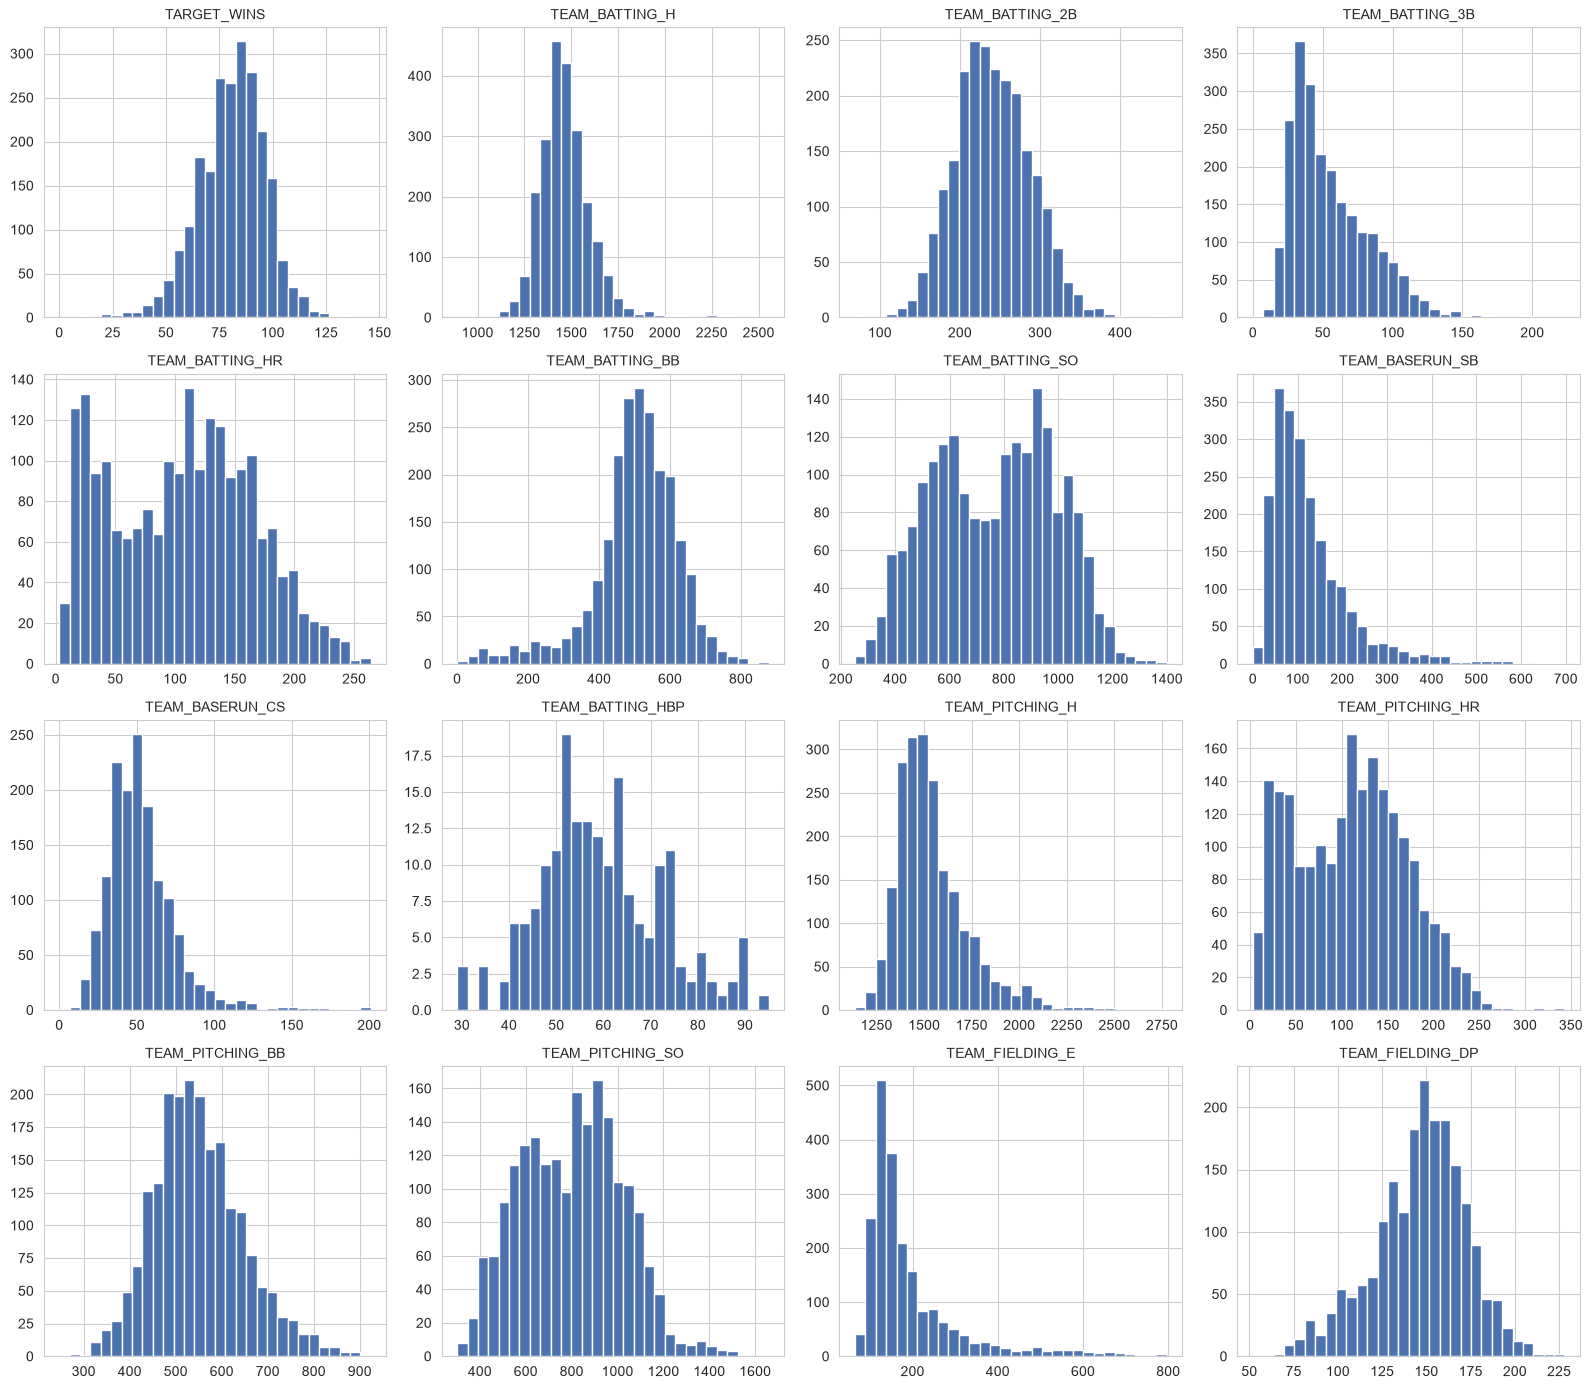

In [24]:
hist_cols = [c for c in train_clean.columns if c not in ['INDEX']]

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()
for ax, col in zip(axes, hist_cols):
    ax.hist(train_clean[col].dropna(), bins=30, color='#4C72B0', edgecolor='white')
    ax.set_title(col, fontsize=10)
for ax in axes[len(hist_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.7 Correlation Analysis

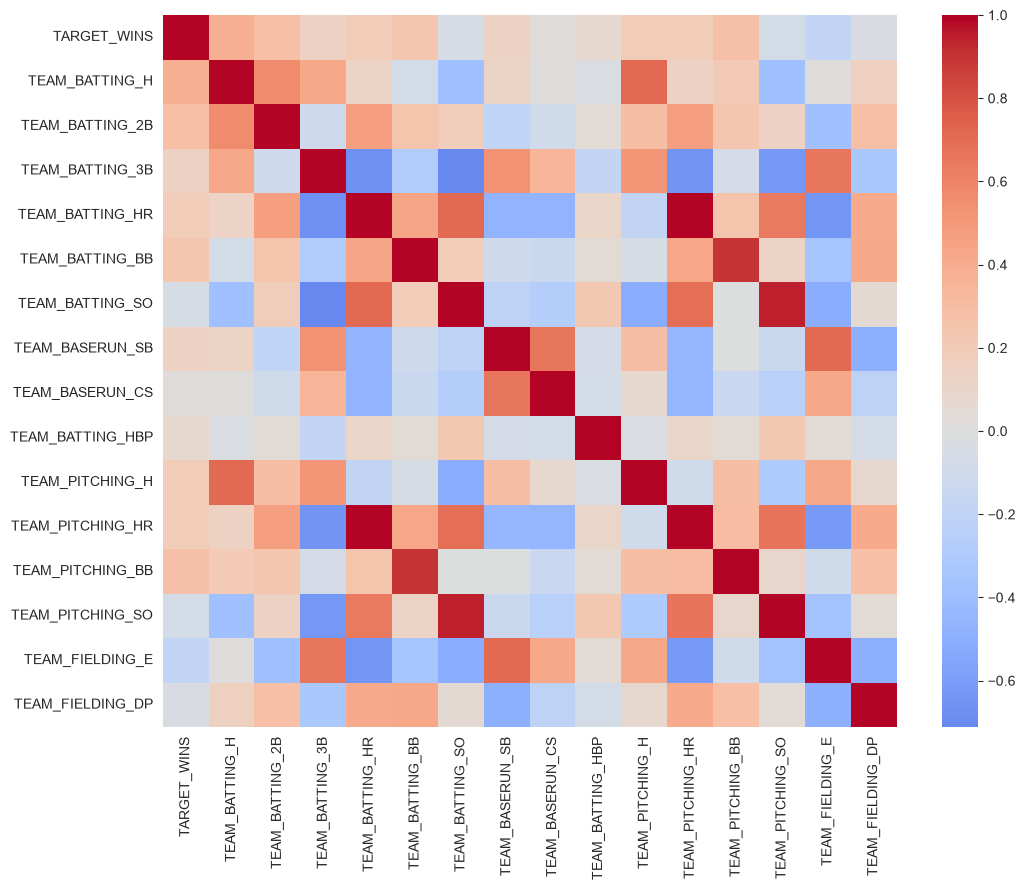

In [26]:
corr_cols = [c for c in train_clean.columns if c not in ['INDEX']]
corr_matrix = train_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=ax)
plt.tight_layout()
plt.show()

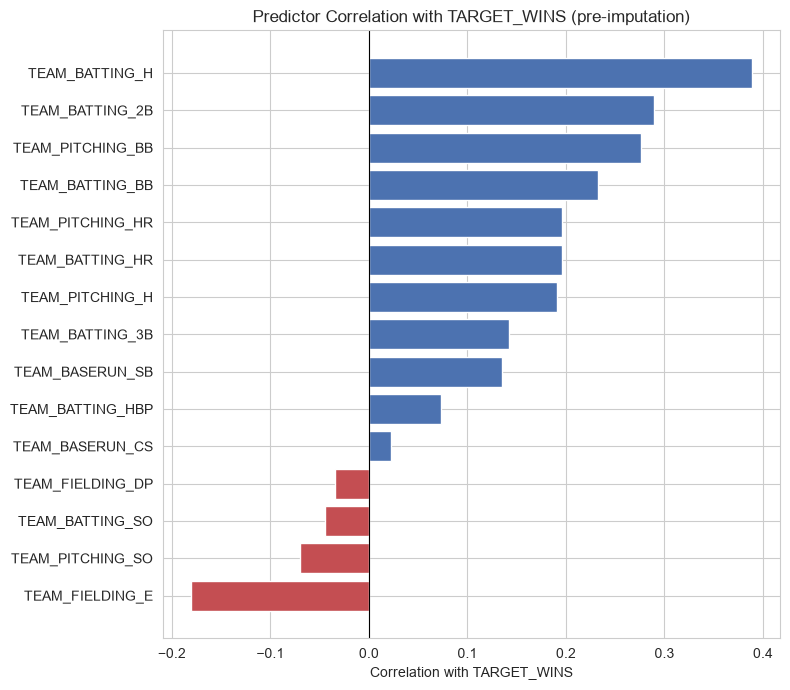

TEAM_BATTING_H      0.388768
TEAM_BATTING_2B     0.289104
TEAM_PITCHING_BB    0.275675
TEAM_BATTING_BB     0.232560
TEAM_PITCHING_HR    0.195834
TEAM_BATTING_HR     0.195509
TEAM_PITCHING_H     0.190694
TEAM_BATTING_3B     0.142608
TEAM_BASERUN_SB     0.135139
TEAM_BATTING_HBP    0.073504
TEAM_BASERUN_CS     0.022404
TEAM_FIELDING_DP   -0.034851
TEAM_BATTING_SO    -0.044785
TEAM_PITCHING_SO   -0.070250
TEAM_FIELDING_E    -0.180890
Name: TARGET_WINS, dtype: float64

In [28]:
target_corr = corr_matrix['TARGET_WINS'].drop('TARGET_WINS').sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with TARGET_WINS')
ax.set_title('Predictor Correlation with TARGET_WINS (pre-imputation)')
plt.tight_layout()
plt.show()

target_corr.sort_values(ascending=False)

**Counterintuitive `TEAM_PITCHING_HR` correlation**: `TEAM_BATTING_HR` and `TEAM_PITCHING_HR` are correlated at $r = 0.969$. Both are driven by the same league-wide offensive era, not by one team's pitching quality. Fitting `TARGET_WINS ~ TEAM_BATTING_HR` alone gives a sensible positive, significant coefficient. Adding `TEAM_PITCHING_HR` to that same model flips the sign on `TEAM_BATTING_HR` to negative and makes it insiginificant, while `TEAM_PITCHING_HR` itself comes out positive and significant. This does not sound correct by baseball logic. This is an example of multicollinearity and it's a flag to revisit when selecting predictors for the models. 

In [30]:
import statsmodels.api as sm

X_a = sm.add_constant(train_clean[['TEAM_BATTING_HR']])
model_a = sm.OLS(train_clean['TARGET_WINS'], X_a, missing='drop').fit()

X_b = sm.add_constant(train_clean[['TEAM_BATTING_HR', 'TEAM_PITCHING_HR']])
model_b = sm.OLS(train_clean['TARGET_WINS'], X_b, missing='drop').fit()

print("Model A: TARGET_WINS ~ TEAM_BATTING_HR")
print(f"  coef = {model_a.params['TEAM_BATTING_HR']:.4f}, p = {model_a.pvalues['TEAM_BATTING_HR']:.4f}")
print()
print("Model B: TARGET_WINS ~ TEAM_BATTING_HR + TEAM_PITCHING_HR")
print(f"  TEAM_BATTING_HR  coef = {model_b.params['TEAM_BATTING_HR']:.4f}, p = {model_b.pvalues['TEAM_BATTING_HR']:.4f}")
print(f"  TEAM_PITCHING_HR coef = {model_b.params['TEAM_PITCHING_HR']:.4f}, p = {model_b.pvalues['TEAM_PITCHING_HR']:.4f}")

Model A: TARGET_WINS ~ TEAM_BATTING_HR
  coef = 0.0471, p = 0.0000

Model B: TARGET_WINS ~ TEAM_BATTING_HR + TEAM_PITCHING_HR
  TEAM_BATTING_HR  coef = 0.0205, p = 0.5428
  TEAM_PITCHING_HR coef = 0.0265, p = 0.4214


---
## Section 2: Data Preparation

### 2.1 Median Imputation

Seven columns now have missing values that originate either from genuinely unrecorded stats (`TEAM_BATTING_SO`, part of `TEAM_PITCHING_SO`) or from the widened outlier repair (`TEAM_PITCHING_H`, `TEAM_PITCHING_BB`, `TEAM_PITCHING_SO`, `TEAM_FIELDING_E`, `TEAM_BATTING_HR`, `TEAM_PITCHING_HR`).  

**Decision**: use median substitution consistently across all seven, rather than switching methods column-by-column. Median is robust regardless of skew, so one consistent, simple rule is used for this baseline. 

Medians are computed from the training data only, then stored, so the exact same values can later be applied to `test.csv` without leakage. 

In [32]:
impute_median_cols = ['TEAM_BATTING_SO', 'TEAM_PITCHING_SO', 'TEAM_PITCHING_H',
                       'TEAM_PITCHING_BB', 'TEAM_FIELDING_E', 'TEAM_BATTING_HR',
                       'TEAM_PITCHING_HR']

train_medians = train_clean[impute_median_cols].median()
print("Medians (computed on train_clean, to be reused on test later):")
print(train_medians)

train_imputed = train_clean.copy()
for c in impute_median_cols:
    train_imputed[c] = train_imputed[c].fillna(train_medians[c])

print()
print("Remaining missing values in these columns after imputation:")
print(train_imputed[impute_median_cols].isna().sum())

Medians (computed on train_clean, to be reused on test later):
TEAM_BATTING_SO      786.0
TEAM_PITCHING_SO     814.0
TEAM_PITCHING_H     1501.0
TEAM_PITCHING_BB     539.0
TEAM_FIELDING_E      153.0
TEAM_BATTING_HR      109.0
TEAM_PITCHING_HR     112.0
dtype: float64

Remaining missing values in these columns after imputation:
TEAM_BATTING_SO     0
TEAM_PITCHING_SO    0
TEAM_PITCHING_H     0
TEAM_PITCHING_BB    0
TEAM_FIELDING_E     0
TEAM_BATTING_HR     0
TEAM_PITCHING_HR    0
dtype: int64


### 2.2 Missing-Indicator Flag: `TEAM_BATTING_HBP`

`TEAM_BATTING_HBP` is missing in ~92% of rows, likely because hit by pitch wasn't tracked across all of baseball's history. Rather than dropping the column outright, we keep both: 
- `TEAM_BATTING_HBP_WAS_MISSING`: binary flag (1 = originally missing, 0 = originally recorded). This captures the era/availability signal, which may correlate with wins.
- `TEAM_BATTING_HBP`: median-imputed for modeling, so the column has no missing values.

This comination (flag + impute) means the model gets to use whichever signal proves useful, rather than guessing in advance. 

In [34]:
train_imputed['TEAM_BATTING_HBP_WAS_MISSING'] = train_clean['TEAM_BATTING_HBP'].isna().astype(int)

hbp_median = train_clean['TEAM_BATTING_HBP'].median()
train_imputed['TEAM_BATTING_HBP'] = train_clean['TEAM_BATTING_HBP'].fillna(hbp_median)

print(f"TEAM_BATTING_HBP median used for imputation: {hbp_median}")
print(train_imputed[['TEAM_BATTING_HBP', 'TEAM_BATTING_HBP_WAS_MISSING']].head(10))
print()
print(train_imputed['TEAM_BATTING_HBP_WAS_MISSING'].value_counts())

TEAM_BATTING_HBP median used for imputation: 58.0
   TEAM_BATTING_HBP  TEAM_BATTING_HBP_WAS_MISSING
0              58.0                             1
1              58.0                             1
2              58.0                             1
3              58.0                             1
4              58.0                             1
5              58.0                             1
6              58.0                             1
7              58.0                             1
8              58.0                             1
9              58.0                             1

TEAM_BATTING_HBP_WAS_MISSING
1    2085
0     191
Name: count, dtype: int64


### 2.3 Median Imputation: Remaining Columns

`TEAM_BASERUN_CS`, `TEAM_FIELDING_OP`, and `TEAM_BASERUN_SB` are missing less extremely (34%, 13%, and 6% respectively) than `TEAM_BATTING_HBP`. 

**DECISION**: plain median imputation for all three, with no missing-indicator flag. Consistent with the median-substition rule used, without adding extra engineered columns where the missingness isn't extreme enough to clearly warrant flagging. 

In [36]:
remaining_median_cols = ['TEAM_BASERUN_CS', 'TEAM_FIELDING_DP', 'TEAM_BASERUN_SB']

remaining_medians = train_clean[remaining_median_cols].median()
print("Medians (computed on train_clean):")
print(remaining_medians)

for c in remaining_median_cols:
    train_imputed[c] = train_imputed[c].fillna(remaining_medians[c])

print()
print("Missing values remaining anywhere in train_imputed:")
print(train_imputed.isna().sum().sum())

Medians (computed on train_clean):
TEAM_BASERUN_CS      49.0
TEAM_FIELDING_DP    149.0
TEAM_BASERUN_SB     101.0
dtype: float64

Missing values remaining anywhere in train_imputed:
0


### 2.4 Feature Engineering: `OFFENSE_PROXY`

Combines the batting components into a single offensive-production measure. 

**Total Bases** is computed from existing columns: `TEAM_BATTING_H + TEAM_BATTING_2B + 2*TEAM_BATTING_3B + 3*TEAM_BATTING_HR` (avoids double-counting, since `TEAM_BATTING_H` already includes every double/triple/HR as one hit each). Walks are added on, since they're another way of safely reaching base:

`OFFENSE_PROXY = TEAM_BATTING_TB + TEAM_BATTING_BB`

Two things tried / rejected: 
1. Estimated run differential (`OFFENSE_PROXY` minus an equivalent pitching-side proxy): correlation `TARGET_WINS` dropped to 0.16, well below `OFFENSE_PROXY` alone (0.43). The pitching-side proxy is missing doubles/triples allowed (not available in dataset), making it too noisy and incomparable in scale to subtract from the batting side.
2. Data-driven re-weighting (regressing `TARGET_WINS` on singles/2B/3B/HR/BB separately to let the data set the weights instead of standard slugging weights): produced an insignificant coefficient for doubles and an implausibly large one for triples, undermined by the same multicolinearity problem seen throughout the dataset, plus the instability that comes from triples being a rare event. The standard, theory-grounded 1-2-3-4 weighting is kept instead.

**Note**: `OFFENSE_PROXY` is built directly from `TEAM_BATTING_H`, `2B`, `3B`, `HR`, and `BB`. It will be used as a substitute for those raw columns in one of the models, not alongside them. Including both would reproduce the exact multicolinearity problem already diagnosed. 

In [38]:
train_imputed['TEAM_BATTING_TB'] = (train_imputed['TEAM_BATTING_H']
                                     + train_imputed['TEAM_BATTING_2B']
                                     + 2 * train_imputed['TEAM_BATTING_3B']
                                     + 3 * train_imputed['TEAM_BATTING_HR'])

train_imputed['OFFENSE_PROXY'] = train_imputed['TEAM_BATTING_TB'] + train_imputed['TEAM_BATTING_BB']

print(train_imputed[['TEAM_BATTING_TB', 'OFFENSE_PROXY']].describe().round(1))
print()
print('Correlation with TARGET_WINS:', train_imputed[['OFFENSE_PROXY','TARGET_WINS']].corr().iloc[0,1].round(3))

       TEAM_BATTING_TB  OFFENSE_PROXY
count           2276.0         2276.0
mean            2138.3         2639.8
std              264.6          306.6
min             1353.0         1353.0
25%             1959.8         2443.0
50%             2142.0         2646.5
75%             2301.0         2839.0
max             3509.0         3787.0

Correlation with TARGET_WINS: 0.439


### 2.5 Log Transformations

`TEAM_FIELDING_E` (skew 2.50) and `TEAM_PITCHING_H` (skew 1.53) were the two most skewed predictors remaining after imputation. Both sqrt and log were tested empirically rather than assumed: log reduced skew more than sqrt for both columns (1.19 vs 1.82 for `FIELDING_E`; 1.04 vs 1.27 for `PITCHING_H`), so log is used for both. 

These are added as new columns (`_LOG` suffix) rather than replacing the originals, so we can compare models with and without the transformation. Since the log has no parameters fit from the training window (unlike the medians used for imputation), the identical transform can be applied to `test.csv` later with no risk of data leakage.

In [43]:
train_imputed['TEAM_FIELDING_E_LOG'] = np.log(train_imputed['TEAM_FIELDING_E'])
train_imputed['TEAM_PITCHING_H_LOG'] = np.log(train_imputed['TEAM_PITCHING_H'])

print('TEAM_FIELDING_E skew before:', train_imputed['TEAM_FIELDING_E'].skew().round(2),
      ' after log:', train_imputed['TEAM_FIELDING_E_LOG'].skew().round(2))
print('TEAM_PITCHING_H skew before:', train_imputed['TEAM_PITCHING_H'].skew().round(2),
      ' after log:', train_imputed['TEAM_PITCHING_H_LOG'].skew().round(2))

TEAM_FIELDING_E skew before: 2.5  after log: 1.19
TEAM_PITCHING_H skew before: 1.53  after log: 1.04


### 2.6 Binning: LOW_HR_ERA

`TEAM_BATTING_HR` and `TEAM_PITCHING_HR` are both bimodal, for the same underlying reason (the dead-ball vs. live-ball era split). The two columns are correlated at r = 0.969, since they're really measuring the same era effect from two angles. A single linear slope across a sparsely-populated valley between two clusters mostly reflects the gap between cluster averages, not a genuine within-cluster relationship. 

**Bin boundary**: the histogram's vally bottoms out around 80-90 home runs; HR < 84 is used as the cutoff for `LOW_HR_ERA` (1 = low-offense/dead ball era profile, 0 = modern/live ball profile), based on `TEAM_BATTING_HR`. 

**Usage**: `TEAM_BATTING_HR` and `TEAM_PITCHING_HR` are themselves near-duplicates of each other, `LOW_HR_ERA` is intended to replace both raw columns at once in the model variant where it's used, including the flag alongside either raw HR column would reproduce the multicolinearity problem already diagnosed for `OFFENSE_PROXY`. 

In [46]:
train_imputed['LOW_HR_ERA'] = (train_imputed['TEAM_BATTING_HR'] < 84).astype(int)

print(train_imputed['LOW_HR_ERA'].value_counts())
print()
print(train_imputed.groupby('LOW_HR_ERA')[['TARGET_WINS', 'TEAM_BATTING_HR', 'TEAM_PITCHING_HR']].mean().round(1))

LOW_HR_ERA
0    1507
1     769
Name: count, dtype: int64

            TARGET_WINS  TEAM_BATTING_HR  TEAM_PITCHING_HR
LOW_HR_ERA                                                
0                  82.0            138.7             142.7
1                  78.5             41.2              45.0


---
## Section 3: Model Development

**Strategy**: three models, each varying predictors/transformations deliberately: 
1. **Kitchen Sink**: every raw predictor, untransformed. Not expected to be the best model; exists to concretely demonstrate the multicollinearity/sign problems diagnosed earlier.
2. **EDA-Informed**: built using what was actually learned: engineered/transformed variables in place of their problematic raw counterparts.
3. **Parsimonious**: small set of the strongest, least-collinear predictors, prioritizing interpretability.

### 3.1 Model 1: Kitchen Sink

In [58]:
import statsmodels.api as sm

kitchen_sink_cols = ['TEAM_BATTING_H','TEAM_BATTING_2B','TEAM_BATTING_3B','TEAM_BATTING_HR',
                      'TEAM_BATTING_BB','TEAM_BATTING_SO','TEAM_BASERUN_SB','TEAM_BASERUN_CS',
                      'TEAM_BATTING_HBP','TEAM_PITCHING_H','TEAM_PITCHING_HR','TEAM_PITCHING_BB',
                      'TEAM_PITCHING_SO','TEAM_FIELDING_E','TEAM_FIELDING_DP']

X1 = sm.add_constant(train_imputed[kitchen_sink_cols])
y = train_imputed['TARGET_WINS']
model_1 = sm.OLS(y, X1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:            TARGET_WINS   R-squared:                       0.309
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     67.38
Date:                Sun, 28 Jun 2026   Prob (F-statistic):          7.30e-169
Time:                        11:33:43   Log-Likelihood:                -9083.2
No. Observations:                2276   AIC:                         1.820e+04
Df Residuals:                    2260   BIC:                         1.829e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               35.3983      7.253  

### 3.2 Model 2: EDA-Informed

Predictor list, decided from Model 1's results plus everything established in Sections 1-2: 
- `OFFENSE_PROXY` (replaces `TEAM_BATTING_H/2B/3B/HR/BB`)
- `LOW_HR_ERA` (replaces `TEAM_BATTING_HR/TEAM_PITCHING_HR`)
- `TEAM_FIELDING_E_LOG` (replaces raw `TEAM_FIELDING_E`)
- `TEAM_BATTING_HBP_WAS_MISSING` (replaces raw `TEAM_BATTING_HBP`, which was insignificant)
- `TEAM_BATTING_SO`, `TEAM_BASERUN_SB`, `TEAM_PITCHING_SO`, `TEAM_FIELDING_DP` (retained as-is, significant in Model 1; `TEAM_FIELDING_DP`'s negative sign is retained and explained as an opportunity-dependent stat: more baserunners allowed creates more double-play chances, inflating the count even when defense isn't actually better)

Dropped entirely: `TEAM_BASERUN_CS`, raw `TEAM_BATTING_HBP`, `TEAM_PITCHING_H`, `TEAM_PITCHING_BB`. All insignificant in Model 1, and no transformation changes a fundamentally weak relationship with `TARGET_WINS`.

In [63]:
model_2_cols = ['OFFENSE_PROXY', 'LOW_HR_ERA', 'TEAM_FIELDING_E_LOG', 'TEAM_BATTING_HBP_WAS_MISSING',
                'TEAM_BATTING_SO', 'TEAM_BASERUN_SB', 'TEAM_PITCHING_SO', 'TEAM_FIELDING_DP']

print('Correlation between OFFENSE_PROXY and LOW_HR_ERA:',
      train_imputed[['OFFENSE_PROXY', 'LOW_HR_ERA']].corr().iloc[0,1].round(3))
print()

X2 = sm.add_constant(train_imputed[model_2_cols])
model_2 = sm.OLS(y, X2).fit()
print(model_2.summary())

Correlation between OFFENSE_PROXY and LOW_HR_ERA: -0.503

                            OLS Regression Results                            
Dep. Variable:            TARGET_WINS   R-squared:                       0.310
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     127.5
Date:                Sun, 28 Jun 2026   Prob (F-statistic):          9.87e-177
Time:                        11:40:34   Log-Likelihood:                -9081.1
No. Observations:                2276   AIC:                         1.818e+04
Df Residuals:                    2267   BIC:                         1.823e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

**Model 2 results**: $R^2 = 0.310$, adjusted $R^2 = 0.308$ - essentially matching Model 1 (0.309 / 0.304) with 8 predictors instead of 15: same explanatory power, less complexity, and a much cleaner story for every coefficient. 

Two engineering decisions from Sections 1-2 paid off directly: 
- `TEAM_BATTING_HBP_WAS_MISSING` is highly significant (coef = +6.07, p < 0.00001). Teams from the era before HBP was tracked average about 6 more predicted wins, holding everything else constant.
- `LOW_HR_ERA` is also significant (+3.55, p < 0.00001), consistent with the raw groupo averages found earlier.

`TEAM_PITCHING_SO` is retained despite becoming statistically insignificant here (p = 0.594), versus being significant and correctly-signed in Model 1 (+0.058). Likely explanation: `LOW_HR_ERA` is absorbing much of the same broad "which baseball era is this" signal that `TEAM_PITCHING_SO` was partly captured in the largert Model 1. High-strikeout pitching and high-home-run offense both track the modern era, so once one ra-proxy is already in the model, the other no longer contributes distinct information. It's kept in Model 2 anyway for direct comparability with Model 1 and as a documented, explained finding rather than a silently dropped one. 

### 3.3 Model 3: Parsimonious

Top 4 predictors from Model 2, ranked by strength of evidence (|t-statistic|): one offense measure, one defense/error measure, and two smaller but still highly significant correction terms.

Goal: easiest model to explain to a non-technical audience, accepting some loss of explanatory power for simplicity. 

In [67]:
model_3_cols = ['OFFENSE_PROXY', 'TEAM_FIELDING_DP', 'TEAM_FIELDING_E_LOG', 'TEAM_BASERUN_SB']

X3 = sm.add_constant(train_imputed[model_3_cols])
model_3 = sm.OLS(y, X3).fit()
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:            TARGET_WINS   R-squared:                       0.262
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     201.4
Date:                Sun, 28 Jun 2026   Prob (F-statistic):          5.88e-148
Time:                        12:02:20   Log-Likelihood:                -9158.4
No. Observations:                2276   AIC:                         1.833e+04
Df Residuals:                    2271   BIC:                         1.836e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  43.3472    

### 3.4 Multicollinearity Check Across all Three Models (VIF)

Variance Inflation Factor (VIF) is the formal diagnostic for multicollinearity (VIF > 10 is generally concerning, VIF > 100 is severe), used here to confirm how much of the engineering choices actually reduced collinearity model by model. 

In [70]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

model_cols_dict = {
    'Model 1 (Kitchen Sink)': kitchen_sink_cols,
    'Model 2 (EDA-Informed)': model_2_cols,
    'Model 3 (Parsimonious)': model_3_cols,
}

for name, cols in model_cols_dict.items():
    Xv = train_imputed[cols].assign(const=1)
    vifs = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(len(cols))], index=cols)
    print(f'--- {name} ---')
    print(vifs.sort_values(ascending=False).round(1))
    print()

--- Model 1 (Kitchen Sink) ---
TEAM_BATTING_HR     283.6
TEAM_PITCHING_HR    272.8
TEAM_BATTING_SO     110.6
TEAM_PITCHING_SO     90.5
TEAM_PITCHING_H       6.0
TEAM_FIELDING_E       3.8
TEAM_BATTING_H        3.7
TEAM_BATTING_3B       2.8
TEAM_BATTING_BB       2.7
TEAM_PITCHING_BB      2.5
TEAM_BATTING_2B       2.4
TEAM_BASERUN_SB       2.1
TEAM_FIELDING_DP      1.4
TEAM_BASERUN_CS       1.2
TEAM_BATTING_HBP      1.0
dtype: float64

--- Model 2 (EDA-Informed) ---
TEAM_BATTING_SO                 14.9
TEAM_PITCHING_SO                11.7
TEAM_FIELDING_E_LOG              3.4
LOW_HR_ERA                       2.8
OFFENSE_PROXY                    1.7
TEAM_BASERUN_SB                  1.6
TEAM_BATTING_HBP_WAS_MISSING     1.3
TEAM_FIELDING_DP                 1.3
dtype: float64

--- Model 3 (Parsimonious) ---
TEAM_FIELDING_E_LOG    1.8
TEAM_BASERUN_SB        1.5
OFFENSE_PROXY          1.4
TEAM_FIELDING_DP       1.2
dtype: float64



### 3.5 Model Comparison Summary

| | Model 1: Kitchen Sink | Model 2: EDA-Informed | Model 3: Parsimonious |
| --- | --- | --- | --- |
| Predictors | 15 | 8 | 4 |
| $R^2$ | 0.309 | 0.310 | 0.262 |
| Adjusted $R^2$ | 0.304 | 0.308 | 0.261 |
| Worst VIF | 283.6 | 14.9 | 1.8 | 
| Insignificant predictors | 5 of 15 | 1 of 8 (called-out) | 0 of 4 |

Model 2 matches Model 1's fit with roughly half of the predictors and a dramatically smaller multicollinearity problem; Model 3 trades a meaningful chunk of $R^2$ for maximum simplicity and a collinearity-free coefficient table. 

### 3.6 Selected Model: Model 2 (EDA-Informed)

Model 2 is selected for this project. It matches Model 1's predictive performance ($R^2$ = 0.310 vs. 0.309) with roughly half the predictors and a dramatically smaller multicollinearity problem (worst VIF 14.9 vs. 283.6), making it the strongest combination of accuracy and reliability among the three. 

**Note on model choice depending on the audience**: for a purely academic/performance-driven goal, Model 2 is the right choice. In a business setting, however, Model 3 (Parsimonious) would likely be the preferable choice despite its lower $R^2$ (0.262). Executive stakeholders typically value simplicity and explanability enough to accept some loss of predictive accuracy, especially when a 4-predictor model with zero meaningful multicollinearity is far easier to communicate and defend than an 8-predictor model with several engineered transformations). 

---
## Section 4: Model Equation & Scored Predictions

### 4.1 Complete Model Equation (Self-Contained)

Every number below is frozen from `train.csv` - none of it is recalculated from `test.csv`, per the train/test methodology established in Section 2. 

**Step 1 - Detect corrupted records**. For each record, count how many are true: 
- `TEAM_PITCHING_H` > 2077.75
- `TEAM_PITCHING_BB` > 813.5
- `TEAM_PITCHING_SO` > 1497.5
- `TEAM_FIELDING_E` > 432.62

If 2 or more are true, treat that record's `TEAM_BATTING_HR`, `TEAM_PITCHING_SO`, `TEAM_BATTING_SO`, and `TEAM_FIELDING_E` values as missing (this catches the scaling/normalization corruption diagnosed earlier). 

**Step 2 - Impute missing values**. For any record with a missing value in the columns below, substitute the fixed value shown (computed from `train.csv`):

| Column | Imputed Value |
| --- | --- |
| `TEAM_BATTING_HR` | 109.0 |
| `TEAM_PITCHING_SO` | 814.0 | 
| `TEAM_BATTING_SO` | 786.0 |
| `TEAM_FIELDING_E` | 153.0 |
| `TEAM_FIELDING_DP` | 149.0 |
| `TEAM_BASERUN_SB` | 101.0 |

**Step 3 - Compute engineered features**: 
- `TEAM_BATTING_HBP_WAS_MISSING` = 1 if the record's original `TEAM_BATTING_HBP` is missing, else 0
- `TEAM_BATTING_TB` = `TEAM_BATTING_H` + `TEAM_BATTING_2B` + 2x`TEAM_BATTING_3B` + 3x`TEAM_BATTING_HR`
- `OFFENSE_PROXY` = `TEAM_BATTING_TB` + `TEAM_BATTING_BB`
- `LOW_HR_ERA` = 1 if `TEAM_BATTING_HR` < 84, else 0
- `TEAM_FIELDING_E_LOG` = ln(`TEAM_FIELDING_E`)

**Step 4 - Apply the regression equation**

`P_TARGET_WINS = 88.3996
               + 0.0268 x OFFENSE_PROXY
               + 3.5526 x LOW_HR_ERA
               - 11.6009 x TEAM_FIELDING_E_LOG
               + 6.0665 x TEAM_BATTING_HBP_WAS_MISSING
               - 0.0159 x TEAM_BATTING_SO
               + 0.0411 x TEAM_BASERUN_SB
               + 0.0024 x TEAM_PITCHING_SO
               - 0.1389 x TEAM_FIELDING_DP`

In [78]:
# --- Apply the above pipeline to test.csv ---
test = pd.read_csv('moneyball_test.csv', index_col=0)

# 1: detect corrupted records using the FROZEN train-derived upper bounds
frozen_upper_bounds = {
    'TEAM_PITCHING_H': 2077.75,
    'TEAM_PITCHING_BB': 813.5,
    'TEAM_PITCHING_SO': 1487.5,
    'TEAM_FIELDING_E': 432.62,
}
test_flags = pd.DataFrame(index=test.index)
for c, bound in frozen_upper_bounds.items():
    test_flags[c] = test[c] > bound
test_corrupted = test_flags.sum(axis=1) >= 2
print(f"Test records flagged as corrupted: {test_corrupted.sum()} of {len(test)}")

test_repaired = test.copy()
repair_cols_model2 = ['TEAM_BATTING_HR', 'TEAM_PITCHING_SO', 'TEAM_BATTING_SO', 'TEAM_FIELDING_E']
test_repaired.loc[test_corrupted, repair_cols_model2] = np.nan

# 2: impute with FROZEN train-derived medians
frozen_medians = {
    'TEAM_BATTING_HR': 109.0,
    'TEAM_PITCHING_SO': 814.0,
    'TEAM_BATTING_SO': 786.0,
    'TEAM_FIELDING_E': 153.0,
    'TEAM_FIELDING_DP': 149.0,
    'TEAM_BASERUN_SB': 101.0,
}
for c, m in frozen_medians.items():
    test_repaired[c] = test_repaired[c].fillna(m)

print("Remaining missing values in test_repaired (should be 0):", test_repaired[list(frozen_medians.keys())].isna().sum().sum())

Test records flagged as corrupted: 21 of 259
Remaining missing values in test_repaired (should be 0): 0


In [80]:
# 3: engineered features
test_repaired['TEAM_BATTING_HBP_WAS_MISSING'] = test['TEAM_BATTING_HBP'].isna().astype(int)
test_repaired['TEAM_BATTING_TB'] = (test_repaired['TEAM_BATTING_H']
                                    + test_repaired['TEAM_BATTING_2B']
                                    + 2 * test_repaired['TEAM_BATTING_3B']
                                    + 3 * test_repaired['TEAM_BATTING_HR'])
test_repaired['OFFENSE_PROXY'] = test_repaired['TEAM_BATTING_TB'] + test_repaired['TEAM_BATTING_BB']
test_repaired['LOW_HR_ERA'] = (test_repaired['TEAM_BATTING_HR'] < 84).astype(int)
test_repaired['TEAM_FIELDING_E_LOG'] = np.log(test_repaired['TEAM_FIELDING_E'])

test_repaired[['OFFENSE_PROXY', 'LOW_HR_ERA', 'TEAM_FIELDING_E_LOG', 'TEAM_BATTING_HBP_WAS_MISSING']].describe().round(2)

,OFFENSE_PROXY,LOW_HR_ERA,TEAM_FIELDING_E_LOG,TEAM_BATTING_HBP_WAS_MISSING
count,259.00,259.00,259.00,259.00
mean,2625.75,0.36,5.17,0.93
std,329.92,0.48,0.44,0.26
min,1560.00,0.00,4.29,0.00
25%,2436.50,0.00,4.88,1.00
50%,2650.00,0.00,5.03,1.00
75%,2849.50,1.00,5.39,1.00
max,3605.00,1.00,6.61,1.00


In [82]:
# 4: apply the frozen Model 2 coefficients
coefs = {
    'const': 88.3996,
    'OFFENSE_PROXY': 0.0268,
    'LOW_HR_ERA': 3.5526,
    'TEAM_FIELDING_E_LOG': -11.6009,
    'TEAM_BATTING_HBP_WAS_MISSING': 6.0665,
    'TEAM_BATTING_SO': -0.0159,
    'TEAM_BASERUN_SB': 0.0411,
    'TEAM_PITCHING_SO': 0.0024,
    'TEAM_FIELDING_DP': -0.1389,
}

test_repaired['P_TARGET_WINS'] = (
    coefs['const']
    + coefs['OFFENSE_PROXY'] * test_repaired['OFFENSE_PROXY']
    + coefs['LOW_HR_ERA'] * test_repaired['LOW_HR_ERA']
    + coefs['TEAM_FIELDING_E_LOG'] * test_repaired['TEAM_FIELDING_E_LOG']
    + coefs['TEAM_BATTING_HBP_WAS_MISSING'] * test_repaired['TEAM_BATTING_HBP_WAS_MISSING']
    + coefs['TEAM_BATTING_SO'] * test_repaired['TEAM_BATTING_SO']
    + coefs['TEAM_BASERUN_SB'] * test_repaired['TEAM_BASERUN_SB']
    + coefs['TEAM_PITCHING_SO'] * test_repaired['TEAM_PITCHING_SO']
    + coefs['TEAM_FIELDING_DP'] * test_repaired['TEAM_FIELDING_DP']
)

print(test_repaired['P_TARGET_WINS'].describe().round(2))

count    259.00
mean      80.37
std       10.00
min       43.89
25%       74.64
50%       80.30
75%       85.96
max      111.99
Name: P_TARGET_WINS, dtype: float64


### 4.2 Final Scored Predictions CSV

In [85]:
scored = test_repaired[['INDEX', 'P_TARGET_WINS']].copy()
scored['INDEX'] = scored['INDEX'].astype(int)
scored['P_TARGET_WINS'] = scored['P_TARGET_WINS'].round(2)

print(scored.shape)
print(scored.isna().sum())
print(scored.dtypes)
scored.head()

(259, 2)
INDEX            0
P_TARGET_WINS    0
dtype: int64
INDEX              int64
P_TARGET_WINS    float64
dtype: object


,INDEX,P_TARGET_WINS
0,9,64.37
1,10,63.69
2,14,71.00
3,47,81.72
4,60,70.78


In [89]:
scored.to_csv('scored_predictions.csv', index=False)
print("Saved scored_predictions.csv with", len(scored), "rows and columns:", list(scored.columns))

Saved scored_predictions.csv with 259 rows and columns: ['INDEX', 'P_TARGET_WINS']
